In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

from pathlib import Path
import os
import warnings

os.chdir("..")
pd.set_option("display.max_columns", None)

# Loading data

In [2]:
data_path = Path("data/merged/merged_v4.csv")

data = pd.read_csv(data_path)
data["time"] = pd.to_datetime(data["time"], utc=True).dt.tz_convert("Europe/Kyiv")

In [3]:
data.head(3)

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend,text_length,cluster,news_count_7d,avg_dist_centroid_7d,topic_entropy_7d,dom_cluster_share_7d,news_velocity_7d,centroid_shift_7d,anomaly_count_7d,news_count_30d,avg_dist_centroid_30d,topic_entropy_30d,dom_cluster_share_30d,news_velocity_30d,centroid_shift_30d,anomaly_count_30d
0,2,2022-03-28 00:00:00+03:00,0,0.4,-2.2,43.82,-10.5,0.0,0.0,0,7.6,314.0,1029.0,24.1,2.0,0.0,0,13.0,5.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,86.0,289.0,-3.0,0.0,0.0,0.0,13953.0,9.0,7.0,0.345617,0.59827,0.714286,0.0,0.22995,1.0,29.0,0.396254,0.589003,0.724138,28.0,0.565055,3.0
1,2,2022-03-28 01:00:00+03:00,0,-0.1,-2.5,45.43,-10.5,0.0,0.0,0,6.8,308.6,1029.0,24.1,4.2,0.0,0,8.0,2.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,4.0,0.0,45.0,285.0,-3.0,1.0,0.0,0.0,13953.0,9.0,7.0,0.345617,0.59827,0.714286,0.0,0.22995,1.0,29.0,0.396254,0.589003,0.724138,28.0,0.565055,3.0
2,2,2022-03-28 02:00:00+03:00,0,-0.6,-2.3,47.87,-10.3,0.0,0.0,0,5.0,305.7,1029.0,24.1,3.1,0.0,0,7.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,28.0,269.0,-2.0,2.0,0.0,0.0,13953.0,9.0,7.0,0.345617,0.59827,0.714286,0.0,0.22995,1.0,29.0,0.396254,0.589003,0.724138,28.0,0.565055,3.0


In [4]:
data.isna().sum().sum()

np.int64(0)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 759649 entries, 0 to 759648
Data columns (total 56 columns):
 #   Column                     Non-Null Count   Dtype                      
---  ------                     --------------   -----                      
 0   region_id                  759649 non-null  int64                      
 1   time                       759649 non-null  datetime64[us, Europe/Kyiv]
 2   alarm                      759649 non-null  int64                      
 3   hour_temp                  759649 non-null  float64                    
 4   hour_feelslike             759649 non-null  float64                    
 5   hour_humidity              759649 non-null  float64                    
 6   hour_dew                   759649 non-null  float64                    
 7   hour_precip                759649 non-null  float64                    
 8   hour_precipprob            759649 non-null  float64                    
 9   hour_preciptype            759649 non-null  int6

In [6]:
data[["hour_preciptype", "hour_conditions"]].nunique()

hour_preciptype     6
hour_conditions    16
dtype: int64

In [7]:
print(f"Percent of alarms: {data["alarm"].sum() / len(data):.2%}")

Percent of alarms: 20.51%


In [8]:
data.agg(["min", "max", "mean", "std"])

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend,text_length,cluster,news_count_7d,avg_dist_centroid_7d,topic_entropy_7d,dom_cluster_share_7d,news_velocity_7d,centroid_shift_7d,anomaly_count_7d,news_count_30d,avg_dist_centroid_30d,topic_entropy_30d,dom_cluster_share_30d,news_velocity_30d,centroid_shift_30d,anomaly_count_30d
min,2.000000,2022-02-24 07:00:00+02:00,0.000000,-22.500000,-30.600000,10.170000,-25.900000,0.000000,0.000000,0.000000,0.000000,0.000000,973.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,-31.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,3.000000,0.108198,2.162327e-08,0.400000,-3.000000,0.110284,1.0,18.000000,0.239447,2.162327e-08,0.416667,-8.000000,0.115810,2.000000
max,25.000000,2025-03-01 23:00:00+02:00,1.000000,39.400000,41.500000,100.000000,24.600000,300.000000,100.000000,5.000000,90.000000,360.000000,1050.000000,75.000000,100.000000,10.000000,15.000000,93.000000,48.000000,12.000000,50.000000,58.000000,58.000000,11.000000,10.000000,12.000000,13.000000,13.000000,13.000000,68.000000,68.000000,68.000000,58.000000,23.000000,183.000000,611.000000,31.000000,23.000000,6.000000,1.000000,63298.000000,9.000000,7.000000,0.464887,1.054920e+00,1.000000,3.000000,0.673703,1.0,30.000000,0.500972,1.028184e+00,1.000000,28.000000,0.696373,3.000000
mean,13.649583,2023-09-08 10:15:27.570496+03:00,0.205057,10.645867,9.177292,73.077891,5.258409,0.089004,6.751276,0.428271,11.355368,190.968993,1016.804855,15.201146,65.012696,1.393059,3.182495,8.131634,1.974437,0.498375,0.768113,2.734109,2.312636,0.832007,0.922111,0.872761,0.613939,0.613703,0.613732,2.405941,2.401060,2.750348,2.386862,0.909758,24.094171,190.518450,0.008392,11.504428,3.012323,0.273073,22855.384957,4.530317,5.639975,0.287010,2.514477e-01,0.888245,-0.055302,0.287990,1.0,24.409171,0.389881,3.570666e-01,0.866258,0.327146,0.358799,2.949388
std,7.178774,313 days 03:18:28.568363,0.403743,9.762665,11.267693,19.377127,7.631766,2.134648,25.090809,1.240363,6.541537,105.550187,8.768129,9.726238,37.234412,2.208365,2.192939,9.220652,3.081049,1.058824,2.632370,4.618055,4.217081,1.481756,1.405424,1.413976,1.149619,1.149591,1.149588,4.206180,4.202366,4.484942,4.284483,1.494549,20.697762,83.421423,3.072337,6.920184,1.968209,0.445539,14412.526748,2.911599,0.959687,0.064557,2.844364e-01,0.136176,1.175679,0.099404,0.0,2.409961,0.051115,2.484258e-01,0.119060,4.010401,0.111271,0.219203


In [9]:
target = "alarm"

X = data.copy()
y = X.pop(target)

X["year"] = X["time"].dt.year
X["month"] = X["time"].dt.month
X["day"] = X["time"].dt.day

In [10]:
cat_cols = ["hour_preciptype", "hour_conditions", "is_weekend", "cluster", ]
num_cols = [col for col in X.select_dtypes(include="number").columns if col not in cat_cols]

print(f"Categorical columns:\n{cat_cols}")
print("-"*20)
print(f"Numerical columns:\n{num_cols}")

Categorical columns:
['hour_preciptype', 'hour_conditions', 'is_weekend', 'cluster']
--------------------
Numerical columns:
['region_id', 'hour_temp', 'hour_feelslike', 'hour_humidity', 'hour_dew', 'hour_precip', 'hour_precipprob', 'hour_windspeed', 'hour_winddir', 'hour_pressure', 'hour_visibility', 'hour_cloudcover', 'hour_uvindex', 'messages_count', 'has_threat_sum', 'nlp_артобстрілу', 'nlp_бпла', 'nlp_відбій', 'nlp_відбій_тривоги', 'nlp_дніпропетровська', 'nlp_донецька', 'nlp_запорізька', 'nlp_нікополь', 'nlp_нікополь_нікопольська', 'nlp_нікопольська', 'nlp_повітряна', 'nlp_повітряна_тривога', 'nlp_тривога', 'nlp_тривоги', 'nlp_харківська', 'msg_count_last_3h', 'msg_count_last_24h', 'threat_diff_1h', 'hour_of_day', 'day_of_week', 'text_length', 'news_count_7d', 'avg_dist_centroid_7d', 'topic_entropy_7d', 'dom_cluster_share_7d', 'news_velocity_7d', 'centroid_shift_7d', 'anomaly_count_7d', 'news_count_30d', 'avg_dist_centroid_30d', 'topic_entropy_30d', 'dom_cluster_share_30d', 'news

# Evaluation function with TimeSeries split

In [11]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone
from time import time

cat_cols = ["hour_preciptype", "hour_conditions", "is_weekend", "cluster", ]
num_cols = [col for col in X.select_dtypes(include="number").columns if col not in cat_cols]

model = SGDClassifier(random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), num_cols)
], remainder='passthrough')

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])


def evaluate_model(model, X=X, y=y):

    tss = TimeSeriesSplit(n_splits=5, gap=24 * 7)
    unique_hours = X["time"].sort_values().unique()

    train_auprc_scores = []    
    train_mcc_scores = []
    
    test_auprc_scores = []    
    test_mcc_scores = []

    all_y_true = []
    all_y_pred = []

    training_start = time()

    for fold, (train_idx, test_idx) in enumerate(tss.split(unique_hours)):
        fold_start = time()
        print(f"------------- Fold {fold} -------------")

        train_hours = unique_hours[train_idx]
        test_hours = unique_hours[test_idx]

        train_mask = X["time"].isin(train_hours)
        test_mask = X["time"].isin(test_hours)

        X_train = X[train_mask].drop(columns=["time"])
        y_train = y[train_mask]

        X_test = X[test_mask].drop(columns=["time"])
        y_test = y[test_mask]

        print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
        print(f"Train positive rate: {y_train.mean():.3f}, Test positive rate: {y_test.mean():.3f}")

        fold_model = clone(model)

        print("Training...", end=" ")
        fold_model.fit(X_train, y_train)
        print("Done.")

        print("Evaluating...", end=" ")
        y_prob_train = fold_model.decision_function(X_train)
        train_auprc = average_precision_score(y_train, y_prob_train)
        train_auprc_scores.append(train_auprc)

        y_pred_train = fold_model.predict(X_train)
        train_mcc = matthews_corrcoef(y_train, y_pred_train)
        train_mcc_scores.append(train_mcc)

        y_prob_test = fold_model.decision_function(X_test)
        test_auprc = average_precision_score(y_test, y_prob_test)
        test_auprc_scores.append(test_auprc)

        y_pred_test = fold_model.predict(X_test)
        test_mcc = matthews_corrcoef(y_test, y_pred_test)
        test_mcc_scores.append(test_mcc)
        print("Done.")

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred_test)
        
        print()
        print(f"Train AUPRC: {train_auprc:.3f}  Test AUPRC: {test_auprc:.3f}")
        print(f"Train MCC: {train_mcc:.3f}  Test MCC: {test_mcc:.3f}")
        print(f"Completed in {time() - fold_start:.2f}s.")

    print()
    print("------------- Completed -------------")
    print(f"Train AUPRC : {np.mean(train_auprc_scores):.3f} ± {np.std(train_auprc_scores):.3f}")
    print(f"Test  AUPRC : {np.mean(test_auprc_scores):.3f} ± {np.std(test_auprc_scores):.3f}")
    print(f"Train MCC   : {np.mean(train_mcc_scores):.3f} ± {np.std(train_mcc_scores):.3f}")
    print(f"Test  MCC   : {np.mean(test_mcc_scores):.3f} ± {np.std(train_mcc_scores):.3f}")
    print(f"Completed in: {time() - training_start:.2f}s.")

    scores = pd.DataFrame({"train_auprc": train_auprc_scores,
                           "test_auprc": test_auprc_scores,
                           "train_mcc": train_mcc_scores,
                           "test_mcc": test_mcc_scores})

    cm = confusion_matrix(all_y_true, all_y_pred)
    
    return scores, cm

In [12]:
print("LinearSVC without tunning parameters")
scores_raw, cm = evaluate_model(pipeline)

LinearSVC without tunning parameters
------------- Fold 0 -------------
Train size: 112270, Test size: 121275
Train positive rate: 0.177, Test positive rate: 0.138
Training... Done.
Evaluating... Done.

Train AUPRC: 0.578  Test AUPRC: 0.509
Train MCC: 0.456  Test MCC: 0.419
Completed in 1.81s.
------------- Fold 1 -------------
Train size: 234707, Test size: 125824
Train positive rate: 0.159, Test positive rate: 0.163
Training... Done.
Evaluating... Done.

Train AUPRC: 0.620  Test AUPRC: 0.618
Train MCC: 0.462  Test MCC: 0.481
Completed in 3.11s.
------------- Fold 2 -------------
Train size: 359989, Test size: 137128
Train positive rate: 0.159, Test positive rate: 0.188
Training... Done.
Evaluating... Done.

Train AUPRC: 0.603  Test AUPRC: 0.539
Train MCC: 0.458  Test MCC: 0.376
Completed in 3.45s.
------------- Fold 3 -------------
Train size: 496083, Test size: 133601
Train positive rate: 0.167, Test positive rate: 0.258
Training... Done.
Evaluating... Done.

Train AUPRC: 0.614  Tes

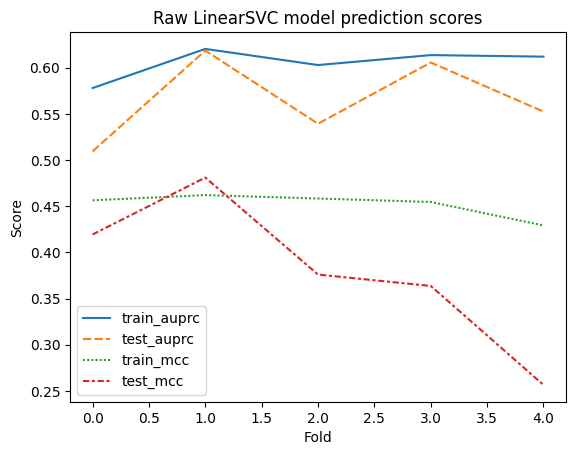

In [13]:
sns.lineplot(scores_raw)

plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Raw LinearSVC model prediction scores")
plt.show()

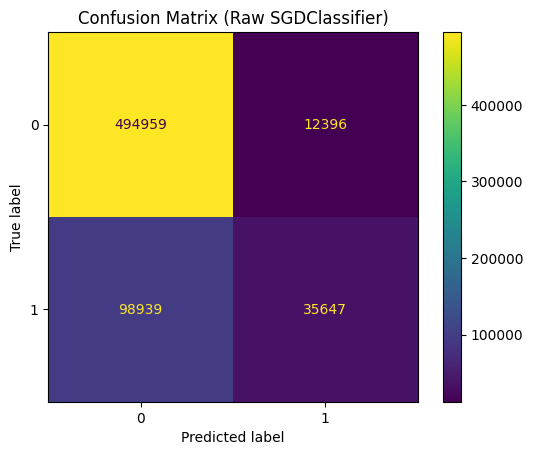

In [14]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Raw SGDClassifier)")
plt.show()

# Try some parameters tunning

In [15]:
loss_funcs = ["hinge", "log_loss", "modified_huber"]
mcc_scores = pd.DataFrame()

for loss_func in loss_funcs:
    
    print(f"loss='{loss_func}'")
    model = SGDClassifier(random_state=42,
                          loss=loss_func)
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores, _ = evaluate_model(pipeline)
    # mcc_scores[f"{loss_func}_train"] = scores["train_mcc"]
    mcc_scores[f"{loss_func}_test"] = scores["test_mcc"]
    print()

loss='hinge'
------------- Fold 0 -------------
Train size: 112270, Test size: 121275
Train positive rate: 0.177, Test positive rate: 0.138
Training... Done.
Evaluating... Done.

Train AUPRC: 0.578  Test AUPRC: 0.509
Train MCC: 0.456  Test MCC: 0.419
Completed in 1.60s.
------------- Fold 1 -------------
Train size: 234707, Test size: 125824
Train positive rate: 0.159, Test positive rate: 0.163
Training... Done.
Evaluating... Done.

Train AUPRC: 0.620  Test AUPRC: 0.618
Train MCC: 0.462  Test MCC: 0.481
Completed in 2.56s.
------------- Fold 2 -------------
Train size: 359989, Test size: 137128
Train positive rate: 0.159, Test positive rate: 0.188
Training... Done.
Evaluating... Done.

Train AUPRC: 0.603  Test AUPRC: 0.539
Train MCC: 0.458  Test MCC: 0.376
Completed in 3.31s.
------------- Fold 3 -------------
Train size: 496083, Test size: 133601
Train positive rate: 0.167, Test positive rate: 0.258
Training... Done.
Evaluating... Done.

Train AUPRC: 0.614  Test AUPRC: 0.606
Train MCC

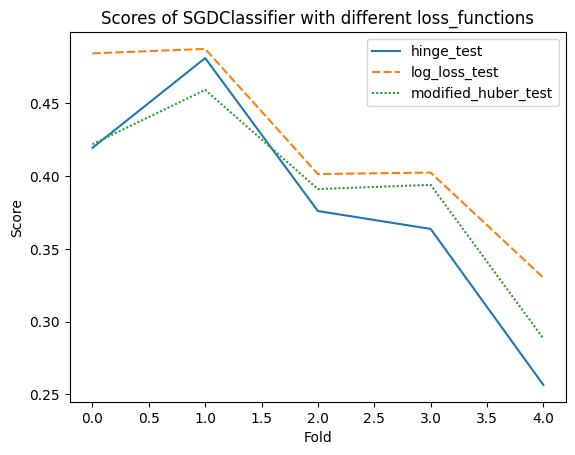

In [16]:
sns.lineplot(mcc_scores)

plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Scores of SGDClassifier with different loss_functions")
plt.show()

`log_loss` performed the best

In [17]:
model = SGDClassifier(
    random_state=42,
    loss='log_loss',
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores_log_loss, cm_log_loss = evaluate_model(pipeline)

------------- Fold 0 -------------
Train size: 112270, Test size: 121275
Train positive rate: 0.177, Test positive rate: 0.138
Training... Done.
Evaluating... Done.

Train AUPRC: 0.582  Test AUPRC: 0.575
Train MCC: 0.454  Test MCC: 0.484
Completed in 1.68s.
------------- Fold 1 -------------
Train size: 234707, Test size: 125824
Train positive rate: 0.159, Test positive rate: 0.163
Training... Done.
Evaluating... Done.

Train AUPRC: 0.633  Test AUPRC: 0.631
Train MCC: 0.491  Test MCC: 0.487
Completed in 2.52s.
------------- Fold 2 -------------
Train size: 359989, Test size: 137128
Train positive rate: 0.159, Test positive rate: 0.188
Training... Done.
Evaluating... Done.

Train AUPRC: 0.629  Test AUPRC: 0.573
Train MCC: 0.488  Test MCC: 0.401
Completed in 2.75s.
------------- Fold 3 -------------
Train size: 496083, Test size: 133601
Train positive rate: 0.167, Test positive rate: 0.258
Training... Done.
Evaluating... Done.

Train AUPRC: 0.621  Test AUPRC: 0.620
Train MCC: 0.467  Test

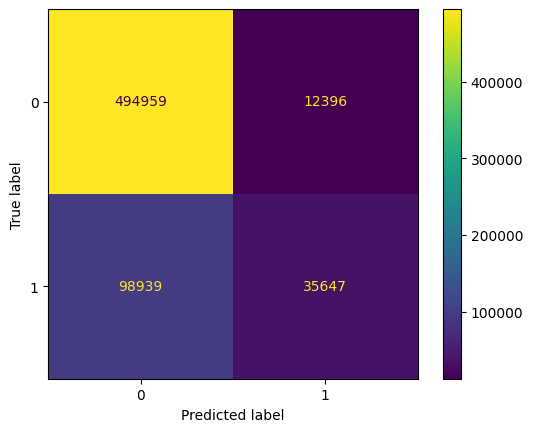

In [18]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

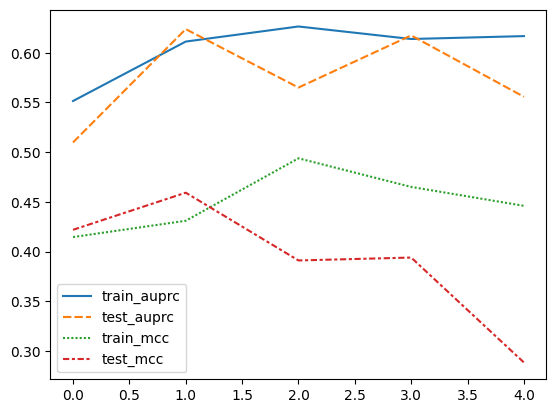

In [19]:
sns.lineplot(scores);


In [20]:
model = SGDClassifier(
    random_state=42,
    loss='log_loss',
    n_iter_no_change=20,
    validation_fraction=0.2,
    alpha=0.001,
    class_weight='balanced'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores, cm = evaluate_model(pipeline)

------------- Fold 0 -------------
Train size: 112270, Test size: 121275
Train positive rate: 0.177, Test positive rate: 0.138
Training... Done.
Evaluating... Done.

Train AUPRC: 0.583  Test AUPRC: 0.604
Train MCC: 0.424  Test MCC: 0.419
Completed in 1.69s.
------------- Fold 1 -------------
Train size: 234707, Test size: 125824
Train positive rate: 0.159, Test positive rate: 0.163
Training... Done.
Evaluating... Done.

Train AUPRC: 0.625  Test AUPRC: 0.629
Train MCC: 0.472  Test MCC: 0.467
Completed in 2.93s.
------------- Fold 2 -------------
Train size: 359989, Test size: 137128
Train positive rate: 0.159, Test positive rate: 0.188
Training... Done.
Evaluating... Done.

Train AUPRC: 0.629  Test AUPRC: 0.572
Train MCC: 0.477  Test MCC: 0.396
Completed in 4.40s.
------------- Fold 3 -------------
Train size: 496083, Test size: 133601
Train positive rate: 0.167, Test positive rate: 0.258
Training... Done.
Evaluating... Done.

Train AUPRC: 0.619  Test AUPRC: 0.624
Train MCC: 0.453  Test

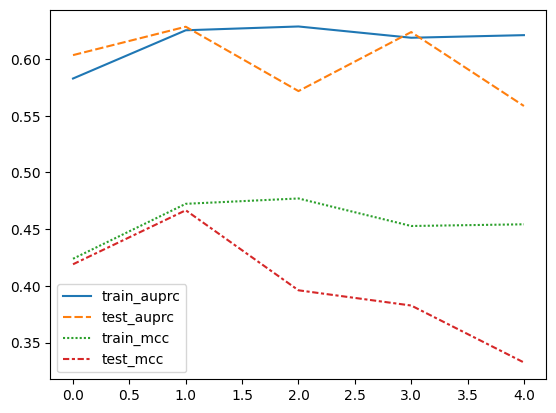

In [21]:
sns.lineplot(scores);


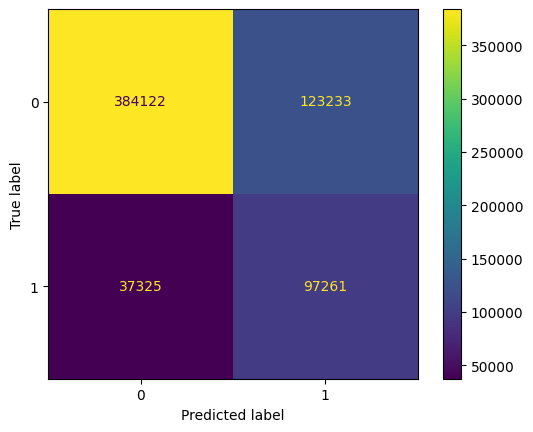

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

This model is better than previuos, because it make less wrong prediction when true value is 1. Cost of that is more wrong predictions for true value 0, but for our problem it is better to wrongly predict that there will be an alarm when it won't than vice versa say that there won't be an alarm when it will be.

# Asked AI to try improve results

## Improvements for Concept Drift

The model shows **concept drift** — performance degrades on later folds because data distribution changes over time.

Three improvements implemented below:
1. **Recency weighting** — give exponentially more weight to recent training samples
2. **Sliding window** — use only the most recent N folds instead of all history
3. **Threshold tuning** — find the optimal MCC decision threshold per fold using a recent calibration slice


## Improvement 1: Recency Weighting

Give exponentially more weight to recent training samples so the model adapts to current patterns rather than treating all historical data equally.

In [23]:
def evaluate_model_with_recency_weights(model, X=X, y=y):
    """Like evaluate_model but applies exponential recency weights during training."""
    tss = TimeSeriesSplit(n_splits=5, gap=24 * 7)
    unique_hours = X["time"].sort_values().unique()
    train_auprc_scores, train_mcc_scores = [], []
    test_auprc_scores, test_mcc_scores = [], []
    all_y_true, all_y_pred = [], []
    training_start = time()

    for fold, (train_idx, test_idx) in enumerate(tss.split(unique_hours)):
        fold_start = time()
        print(f"------------- Fold {fold} -------------")
        train_hours = unique_hours[train_idx]
        test_hours = unique_hours[test_idx]
        train_mask = X["time"].isin(train_hours)
        test_mask = X["time"].isin(test_hours)
        X_train = X[train_mask].drop(columns=["time"])
        y_train = y[train_mask]
        X_test = X[test_mask].drop(columns=["time"])
        y_test = y[test_mask]
        print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
        print(f"Train positive rate: {y_train.mean():.3f}, Test positive rate: {y_test.mean():.3f}")

        # Exponential recency weights: recent samples get more weight
        sample_weights = np.exp(np.linspace(0, 1, len(X_train)))
        sample_weights = sample_weights / sample_weights.sum() * len(X_train)

        # Extract preprocessor and model from pipeline to pass sample_weight
        preprocessor_clone = clone(model.named_steps["preprocessor"])
        model_clone = clone(model.named_steps["model"])
        X_train_t = preprocessor_clone.fit_transform(X_train)
        print("Training...", end=" ")
        model_clone.fit(X_train_t, y_train, sample_weight=sample_weights)
        print("Done.")

        print("Evaluating...", end=" ")
        X_test_t = preprocessor_clone.transform(X_test)
        y_prob_train = model_clone.predict_proba(X_train_t)[:, 1]
        train_auprc = average_precision_score(y_train, y_prob_train)
        train_auprc_scores.append(train_auprc)
        train_mcc_scores.append(matthews_corrcoef(y_train, model_clone.predict(X_train_t)))
        y_prob_test = model_clone.predict_proba(X_test_t)[:, 1]
        test_auprc = average_precision_score(y_test, y_prob_test)
        test_auprc_scores.append(test_auprc)
        y_pred_test = model_clone.predict(X_test_t)
        test_mcc = matthews_corrcoef(y_test, y_pred_test)
        test_mcc_scores.append(test_mcc)
        all_y_true.extend(y_test); all_y_pred.extend(y_pred_test)
        print("Done.")
        print(f"Train AUPRC: {train_auprc:.3f}  Test AUPRC: {test_auprc:.3f}")
        print(f"Train MCC: {train_mcc_scores[-1]:.3f}  Test MCC: {test_mcc:.3f}")
        print(f"Completed in {time() - fold_start:.2f}s.")

    print()
    print("------------- Completed -------------")
    print(f"Train AUPRC : {np.mean(train_auprc_scores):.3f} +/- {np.std(train_auprc_scores):.3f}")
    print(f"Test  AUPRC : {np.mean(test_auprc_scores):.3f} +/- {np.std(test_auprc_scores):.3f}")
    print(f"Train MCC   : {np.mean(train_mcc_scores):.3f} +/- {np.std(train_mcc_scores):.3f}")
    print(f"Test  MCC   : {np.mean(test_mcc_scores):.3f} +/- {np.std(test_mcc_scores):.3f}")
    print(f"Completed in: {time() - training_start:.2f}s.")
    scores = pd.DataFrame({"train_auprc": train_auprc_scores, "test_auprc": test_auprc_scores,
                           "train_mcc": train_mcc_scores, "test_mcc": test_mcc_scores})
    return scores, confusion_matrix(all_y_true, all_y_pred)


model_w = SGDClassifier(random_state=42, loss="log_loss", n_iter_no_change=20,
                        validation_fraction=0.2, alpha=0.001, class_weight="balanced")
pipeline_w = Pipeline([("preprocessor", ColumnTransformer(
    transformers=[("scale", StandardScaler(), num_cols)], remainder="passthrough")),
    ("model", model_w)])

print("=== Recency Weighting ===")
scores_weighted, cm_weighted = evaluate_model_with_recency_weights(pipeline_w)


=== Recency Weighting ===
------------- Fold 0 -------------
Train size: 112270, Test size: 121275
Train positive rate: 0.177, Test positive rate: 0.138
Training... Done.
Evaluating... Done.
Train AUPRC: 0.581  Test AUPRC: 0.608
Train MCC: 0.421  Test MCC: 0.412
Completed in 1.57s.
------------- Fold 1 -------------
Train size: 234707, Test size: 125824
Train positive rate: 0.159, Test positive rate: 0.163
Training... Done.
Evaluating... Done.
Train AUPRC: 0.625  Test AUPRC: 0.630
Train MCC: 0.479  Test MCC: 0.474
Completed in 2.77s.
------------- Fold 2 -------------
Train size: 359989, Test size: 137128
Train positive rate: 0.159, Test positive rate: 0.188
Training... Done.
Evaluating... Done.
Train AUPRC: 0.628  Test AUPRC: 0.570
Train MCC: 0.477  Test MCC: 0.394
Completed in 4.37s.
------------- Fold 3 -------------
Train size: 496083, Test size: 133601
Train positive rate: 0.167, Test positive rate: 0.258
Training... Done.
Evaluating... Done.
Train AUPRC: 0.618  Test AUPRC: 0.620


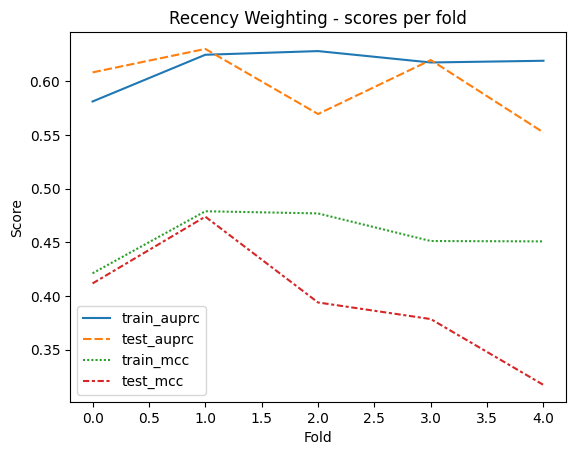

In [24]:
sns.lineplot(scores_weighted)
plt.xlabel("Fold"); plt.ylabel("Score")
plt.title("Recency Weighting - scores per fold")
plt.show()


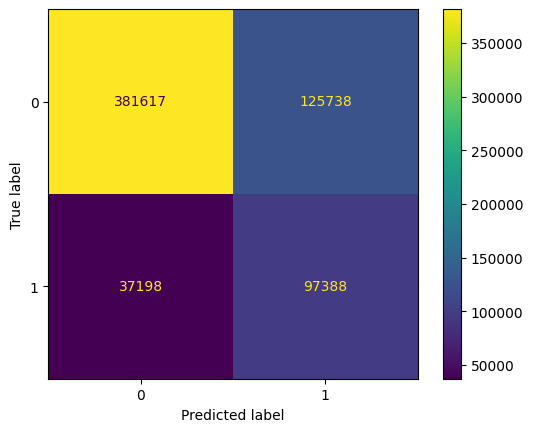

In [38]:
ConfusionMatrixDisplay(confusion_matrix=cm_weighted).plot()
plt.show()

## Improvement 2: Sliding Window

Train only on the most recent `window_size` folds instead of all historical data. This prevents early, potentially obsolete data from dominating the model.

In [25]:
def evaluate_model_sliding_window(model, X=X, y=y, window_size=2):
    """Trains on only the most recent window_size folds of data."""
    tss = TimeSeriesSplit(n_splits=5, gap=24 * 7)
    unique_hours = X["time"].sort_values().unique()
    all_splits = list(tss.split(unique_hours))
    train_auprc_scores, train_mcc_scores = [], []
    test_auprc_scores, test_mcc_scores = [], []
    all_y_true, all_y_pred = [], []
    training_start = time()

    for fold_idx, (train_idx, test_idx) in enumerate(all_splits):
        fold_start = time()
        print(f"------------- Fold {fold_idx} -------------")

        # Build sliding window training set
        if fold_idx == 0:
            window_train_idx = train_idx
        else:
            start_fold = max(0, fold_idx - window_size)
            chunks = []
            for i in range(start_fold, fold_idx):
                prev_train, prev_test = all_splits[i]
                if i == start_fold:
                    chunks.append(prev_train)
                chunks.append(prev_test)
            combined = np.unique(np.concatenate(chunks))
            test_set = set(unique_hours[test_idx])
            window_train_idx = np.array([i for i in combined if unique_hours[i] not in test_set])

        train_hours = unique_hours[window_train_idx]
        test_hours = unique_hours[test_idx]
        train_mask = X["time"].isin(train_hours)
        test_mask = X["time"].isin(test_hours)
        X_train = X[train_mask].drop(columns=["time"])
        y_train = y[train_mask]
        X_test = X[test_mask].drop(columns=["time"])
        y_test = y[test_mask]
        print(f"Train size: {len(X_train)} (window={window_size}), Test size: {len(X_test)}")
        print(f"Train positive rate: {y_train.mean():.3f}, Test positive rate: {y_test.mean():.3f}")

        fold_model = clone(model)
        print("Training...", end=" ")
        fold_model.fit(X_train, y_train)
        print("Done.")

        print("Evaluating...", end=" ")
        y_prob_train = fold_model.predict_proba(X_train)[:, 1]
        train_auprc_scores.append(average_precision_score(y_train, y_prob_train))
        train_mcc_scores.append(matthews_corrcoef(y_train, fold_model.predict(X_train)))
        y_prob_test = fold_model.predict_proba(X_test)[:, 1]
        test_auprc = average_precision_score(y_test, y_prob_test)
        test_auprc_scores.append(test_auprc)
        y_pred_test = fold_model.predict(X_test)
        test_mcc = matthews_corrcoef(y_test, y_pred_test)
        test_mcc_scores.append(test_mcc)
        all_y_true.extend(y_test); all_y_pred.extend(y_pred_test)
        print("Done.")
        print(f"Train AUPRC: {train_auprc_scores[-1]:.3f}  Test AUPRC: {test_auprc:.3f}")
        print(f"Train MCC: {train_mcc_scores[-1]:.3f}  Test MCC: {test_mcc:.3f}")
        print(f"Completed in {time() - fold_start:.2f}s.")

    print()
    print("------------- Completed -------------")
    print(f"Train AUPRC : {np.mean(train_auprc_scores):.3f} +/- {np.std(train_auprc_scores):.3f}")
    print(f"Test  AUPRC : {np.mean(test_auprc_scores):.3f} +/- {np.std(test_auprc_scores):.3f}")
    print(f"Train MCC   : {np.mean(train_mcc_scores):.3f} +/- {np.std(train_mcc_scores):.3f}")
    print(f"Test  MCC   : {np.mean(test_mcc_scores):.3f} +/- {np.std(test_mcc_scores):.3f}")
    print(f"Completed in: {time() - training_start:.2f}s.")
    scores = pd.DataFrame({"train_auprc": train_auprc_scores, "test_auprc": test_auprc_scores,
                           "train_mcc": train_mcc_scores, "test_mcc": test_mcc_scores})
    return scores, confusion_matrix(all_y_true, all_y_pred)


model_s = SGDClassifier(random_state=42, loss="log_loss", n_iter_no_change=20,
                        validation_fraction=0.2, alpha=0.001, class_weight="balanced")
pipeline_s = Pipeline([("preprocessor", ColumnTransformer(
    transformers=[("scale", StandardScaler(), num_cols)], remainder="passthrough")),
    ("model", model_s)])

print("=== Sliding Window (window_size=2) ===")
scores_sliding, cm_sliding = evaluate_model_sliding_window(pipeline_s, window_size=2)


=== Sliding Window (window_size=2) ===
------------- Fold 0 -------------
Train size: 112270 (window=2), Test size: 121275
Train positive rate: 0.177, Test positive rate: 0.138
Training... Done.
Evaluating... Done.
Train AUPRC: 0.583  Test AUPRC: 0.604
Train MCC: 0.424  Test MCC: 0.419
Completed in 1.66s.
------------- Fold 1 -------------
Train size: 233545 (window=2), Test size: 125824
Train positive rate: 0.157, Test positive rate: 0.163
Training... Done.
Evaluating... Done.
Train AUPRC: 0.619  Test AUPRC: 0.630
Train MCC: 0.478  Test MCC: 0.473
Completed in 2.97s.
------------- Fold 2 -------------
Train size: 359369 (window=2), Test size: 137128
Train positive rate: 0.159, Test positive rate: 0.188
Training... Done.
Evaluating... Done.
Train AUPRC: 0.628  Test AUPRC: 0.569
Train MCC: 0.470  Test MCC: 0.392
Completed in 4.15s.
------------- Fold 3 -------------
Train size: 497659 (window=2), Test size: 133601
Train positive rate: 0.168, Test positive rate: 0.258
Training... Done.
E

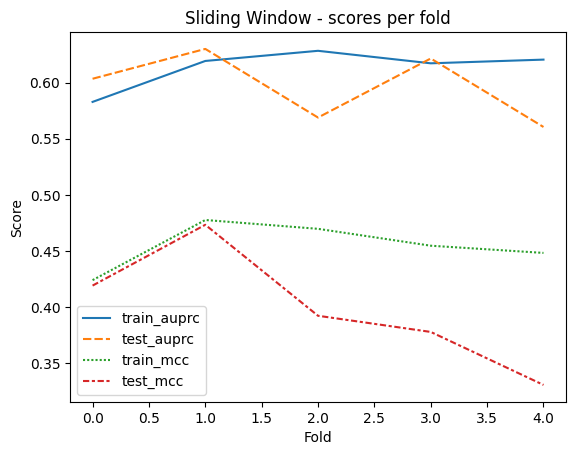

In [26]:
sns.lineplot(scores_sliding)
plt.xlabel("Fold"); plt.ylabel("Score")
plt.title("Sliding Window - scores per fold")
plt.show()


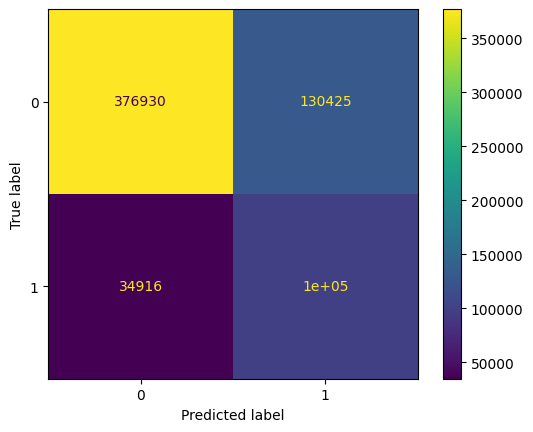

In [37]:
ConfusionMatrixDisplay(confusion_matrix=cm_sliding).plot()
plt.show()

## Improvement 3: Threshold Tuning for MCC

AUPRC degrades slower than MCC across folds - the probability rankings stay OK but the **decision threshold drifts**. We calibrate the threshold per fold using the last 20% of training data as a calibration set.

In [27]:
def evaluate_model_threshold_tuned(model, X=X, y=y, calib_frac=0.2):
    """Finds optimal MCC threshold from last calib_frac of training set, applies to test."""
    tss = TimeSeriesSplit(n_splits=5, gap=24 * 7)
    unique_hours = X["time"].sort_values().unique()
    train_auprc_scores, train_mcc_scores = [], []
    test_auprc_scores, test_mcc_scores = [], []
    best_thresholds = []
    all_y_true, all_y_pred = [], []
    training_start = time()

    for fold, (train_idx, test_idx) in enumerate(tss.split(unique_hours)):
        fold_start = time()
        print(f"------------- Fold {fold} -------------")
        train_hours = unique_hours[train_idx]
        test_hours = unique_hours[test_idx]
        X_train_full = X[X["time"].isin(train_hours)].drop(columns=["time"])
        y_train_full = y[X["time"].isin(train_hours)]
        X_test = X[X["time"].isin(test_hours)].drop(columns=["time"])
        y_test = y[X["time"].isin(test_hours)]

        # Split: fit set + calibration set (last calib_frac)
        n_calib = int(len(X_train_full) * calib_frac)
        X_train = X_train_full.iloc[:-n_calib]
        y_train = y_train_full.iloc[:-n_calib]
        X_calib = X_train_full.iloc[-n_calib:]
        y_calib = y_train_full.iloc[-n_calib:]
        print(f"Train: {len(X_train)}, Calib: {len(X_calib)}, Test: {len(X_test)}")
        print(f"Train positive rate: {y_train.mean():.3f}, Test positive rate: {y_test.mean():.3f}")

        fold_model = clone(model)
        print("Training...", end=" ")
        fold_model.fit(X_train, y_train)
        print("Done.")

        # Find best threshold on calibration set
        y_prob_calib = fold_model.predict_proba(X_calib)[:, 1]
        thresholds = np.linspace(0.05, 0.95, 91)
        calib_mccs = [matthews_corrcoef(y_calib, y_prob_calib >= t) for t in thresholds]
        best_t = thresholds[np.argmax(calib_mccs)]
        best_thresholds.append(best_t)
        print(f"Best threshold (calib): {best_t:.2f}")

        print("Evaluating...", end=" ")
        y_prob_train = fold_model.predict_proba(X_train)[:, 1]
        train_auprc_scores.append(average_precision_score(y_train, y_prob_train))
        train_mcc_scores.append(matthews_corrcoef(y_train, (y_prob_train >= best_t).astype(int)))
        y_prob_test = fold_model.predict_proba(X_test)[:, 1]
        test_auprc = average_precision_score(y_test, y_prob_test)
        test_auprc_scores.append(test_auprc)
        y_pred_test = (y_prob_test >= best_t).astype(int)
        test_mcc = matthews_corrcoef(y_test, y_pred_test)
        test_mcc_scores.append(test_mcc)
        all_y_true.extend(y_test); all_y_pred.extend(y_pred_test)
        print("Done.")
        print(f"Train AUPRC: {train_auprc_scores[-1]:.3f}  Test AUPRC: {test_auprc:.3f}")
        print(f"Train MCC: {train_mcc_scores[-1]:.3f}  Test MCC: {test_mcc:.3f}")
        print(f"Completed in {time() - fold_start:.2f}s.")

    print()
    print("------------- Completed -------------")
    print(f"Best thresholds per fold: {[round(t, 2) for t in best_thresholds]}")
    print(f"Train AUPRC : {np.mean(train_auprc_scores):.3f} +/- {np.std(train_auprc_scores):.3f}")
    print(f"Test  AUPRC : {np.mean(test_auprc_scores):.3f} +/- {np.std(test_auprc_scores):.3f}")
    print(f"Train MCC   : {np.mean(train_mcc_scores):.3f} +/- {np.std(train_mcc_scores):.3f}")
    print(f"Test  MCC   : {np.mean(test_mcc_scores):.3f} +/- {np.std(test_mcc_scores):.3f}")
    print(f"Completed in: {time() - training_start:.2f}s.")
    scores = pd.DataFrame({"train_auprc": train_auprc_scores, "test_auprc": test_auprc_scores,
                           "train_mcc": train_mcc_scores, "test_mcc": test_mcc_scores})
    return scores, confusion_matrix(all_y_true, all_y_pred)


model_t = SGDClassifier(random_state=42, loss="log_loss", n_iter_no_change=20,
                        validation_fraction=0.2, alpha=0.001, class_weight="balanced")
pipeline_t = Pipeline([("preprocessor", ColumnTransformer(
    transformers=[("scale", StandardScaler(), num_cols)], remainder="passthrough")),
    ("model", model_t)])

print("=== Threshold Tuning ===")
scores_thresh, cm_thresh = evaluate_model_threshold_tuned(pipeline_t)


=== Threshold Tuning ===
------------- Fold 0 -------------
Train: 89816, Calib: 22454, Test: 121275
Train positive rate: 0.193, Test positive rate: 0.138
Training... Done.
Best threshold (calib): 0.72
Evaluating... Done.
Train AUPRC: 0.590  Test AUPRC: 0.594
Train MCC: 0.446  Test MCC: 0.486
Completed in 1.58s.
------------- Fold 1 -------------
Train: 187766, Calib: 46941, Test: 125824
Train positive rate: 0.176, Test positive rate: 0.163
Training... Done.
Best threshold (calib): 0.89
Evaluating... Done.
Train AUPRC: 0.643  Test AUPRC: 0.618
Train MCC: 0.475  Test MCC: 0.473
Completed in 2.93s.
------------- Fold 2 -------------
Train: 287992, Calib: 71997, Test: 137128
Train positive rate: 0.178, Test positive rate: 0.188
Training... Done.
Best threshold (calib): 0.92
Evaluating... Done.
Train AUPRC: 0.646  Test AUPRC: 0.563
Train MCC: 0.469  Test MCC: 0.390
Completed in 3.87s.
------------- Fold 3 -------------
Train: 396867, Calib: 99216, Test: 133601
Train positive rate: 0.189, T

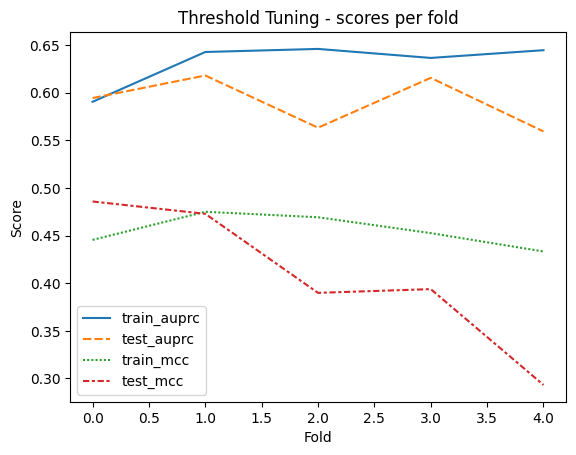

In [28]:
sns.lineplot(scores_thresh)
plt.xlabel("Fold"); plt.ylabel("Score")
plt.title("Threshold Tuning - scores per fold")
plt.show()


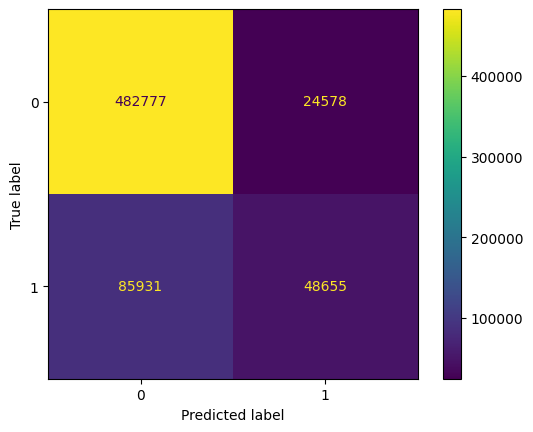

In [36]:
ConfusionMatrixDisplay(confusion_matrix=cm_thresh).plot()
plt.show()

## Comparison: Test MCC Across All Approaches

Which approach best combats concept drift?

------------- Fold 0 -------------
Train size: 112270, Test size: 121275
Train positive rate: 0.177, Test positive rate: 0.138
Training... Done.
Evaluating... Done.

Train AUPRC: 0.583  Test AUPRC: 0.604
Train MCC: 0.424  Test MCC: 0.419
Completed in 1.54s.
------------- Fold 1 -------------
Train size: 234707, Test size: 125824
Train positive rate: 0.159, Test positive rate: 0.163
Training... Done.
Evaluating... Done.

Train AUPRC: 0.625  Test AUPRC: 0.629
Train MCC: 0.472  Test MCC: 0.467
Completed in 2.84s.
------------- Fold 2 -------------
Train size: 359989, Test size: 137128
Train positive rate: 0.159, Test positive rate: 0.188
Training... Done.
Evaluating... Done.

Train AUPRC: 0.629  Test AUPRC: 0.572
Train MCC: 0.477  Test MCC: 0.396
Completed in 4.04s.
------------- Fold 3 -------------
Train size: 496083, Test size: 133601
Train positive rate: 0.167, Test positive rate: 0.258
Training... Done.
Evaluating... Done.

Train AUPRC: 0.619  Test AUPRC: 0.624
Train MCC: 0.453  Test

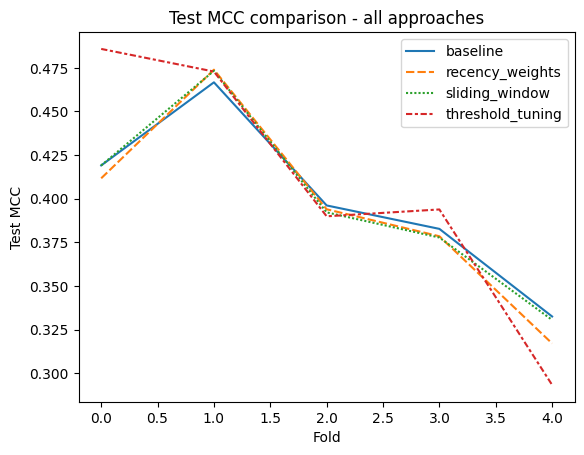

In [29]:
# Re-run baseline with same params for clean comparison
model_base = SGDClassifier(random_state=42, loss="log_loss", n_iter_no_change=20,
                           validation_fraction=0.2, alpha=0.001, class_weight="balanced")
pipeline_base = Pipeline([("preprocessor", ColumnTransformer(
    transformers=[("scale", StandardScaler(), num_cols)], remainder="passthrough")),
    ("model", model_base)])
scores_base, _ = evaluate_model(pipeline_base)

comparison = pd.DataFrame({
    "baseline": scores_base["test_mcc"],
    "recency_weights": scores_weighted["test_mcc"],
    "sliding_window": scores_sliding["test_mcc"],
    "threshold_tuning": scores_thresh["test_mcc"],
})

print("Test MCC per fold:")
print(comparison.to_string())
print()
print("Mean Test MCC:")
print(comparison.mean().round(3).to_string())

sns.lineplot(comparison)
plt.xlabel("Fold")
plt.ylabel("Test MCC")
plt.title("Test MCC comparison - all approaches")
plt.show()


Nothing changed much

# Final model

Chose my best last model as final variant

In [30]:
model = SGDClassifier(
    random_state=42,
    loss='log_loss',
    n_iter_no_change=20,
    validation_fraction=0.2,
    alpha=0.001,
    class_weight='balanced'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# pipeline.fit(X, y)

Try different training

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X.drop(columns="time"), y, test_size=0.2)

pipeline.fit(X_train, y_train)

train_pred = pipeline.predict(X_train)
test_pred = pipeline.predict(X_test)

train_score = matthews_corrcoef(y_train, train_pred)
test_score = matthews_corrcoef(y_test, test_pred)

print(f"train: {train_score}, test: {test_score}")

train: 0.442490859248046, test: 0.44256834635673054


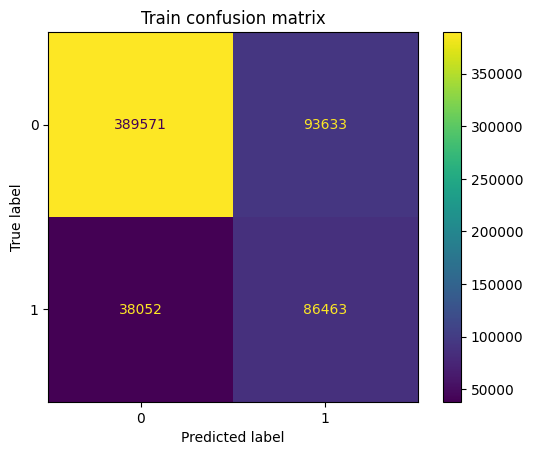

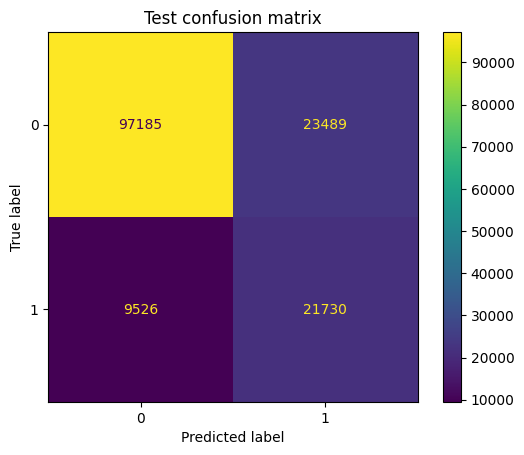

In [32]:
train_cm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_train, train_pred))
test_cm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, test_pred))

train_cm.plot()
plt.title("Train confusion matrix")

test_cm.plot()
plt.title("Test confusion matrix")

plt.show()

almost same results as before

## What the metrics mean

**Confusion Matrix cells:**
- **TN (True Negative):** Correctly predicted class 0 - Train: 392,266 | Test: 97,974
- **FP (False Positive):** Predicted 1, actually 0 - Train: 90,846 | Test: 22,792
- **FN (False Negative):** Predicted 0, actually 1 - Train: 38,960 | Test: 9,780
- **TP (True Positive):** Correctly predicted class 1 - Train: 85,647 | Test: 21,384

**MCC (Matthews Correlation Coefficient):**
- Ranges from -1 (worst) to +1 (perfect), 0 = random
- Train: **0.444**, Test: **0.442** - moderate predictive ability
- MCC is robust to class imbalance (class 0 is ~3× larger than class 1)

**Key observations:**
- High FP (90k train) - model over-predicts positive class, but for our needs it is better than fn
- Train ≈ Test scores - **no significant overfitting**

## Final training and saving

In [33]:
import pickle
from pathlib import Path

pipeline.fit(X.drop(columns="time"), y)

print("Training...")
models_dir = Path("app/models")

if not models_dir.exists():
    models_dir.mkdir(exist_ok=True, parents=True)

print("Saving...")
with open(models_dir / "SGDClassifier_v1.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Success.")

Training...
Saving...
Success.


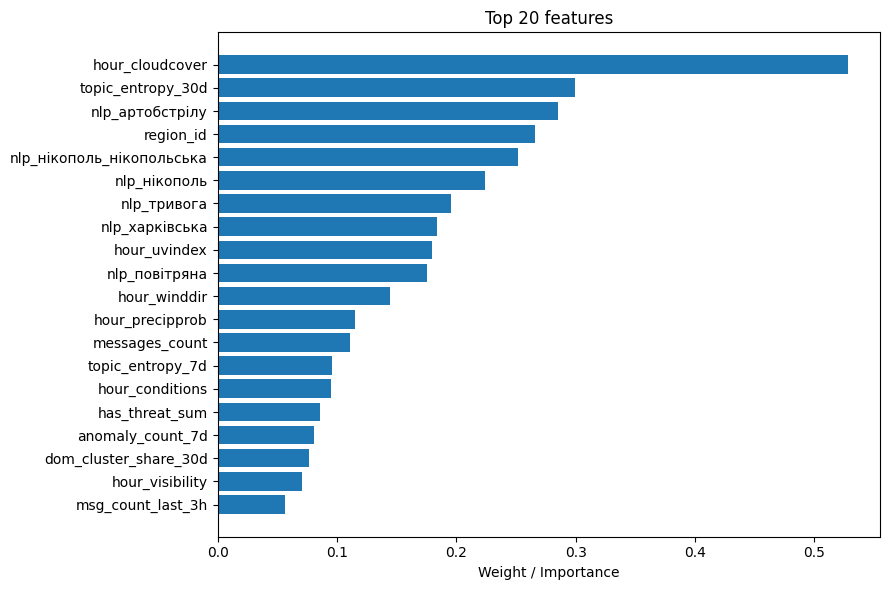

In [34]:
def get_top_features(pipeline, feature_names, top_n=20):
    """Extract top N features and their weights from a fitted pipeline."""
    model = pipeline.named_steps["model"]
    
    # Tree-based models
    if hasattr(model, "feature_importances_"):
        weights = model.feature_importances_
    # Linear models (coef_ is 2D for multi-class, 1D for binary)
    elif hasattr(model, "coef_"):
        weights = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim > 1 else np.abs(model.coef_[0])
    else:
        raise ValueError("Model has no feature_importances_ or coef_")

    indices = np.argsort(weights)[::-1][:top_n]
    return [(feature_names[i], weights[i]) for i in indices]

def get_feature_names_from_pipeline(pipeline):
    """Works when pipeline has a ColumnTransformer step named 'preprocessor'."""
    ct = pipeline.named_steps["preprocessor"]
    return ct.get_feature_names_out()


top_features = get_top_features(pipeline, X.columns, top_n=20)

fig = plt.figure(figsize=(9, 6))
names, weights = zip(*top_features)
plt.barh(names[::-1], weights[::-1])
plt.title("Top 20 features")
plt.xlabel("Weight / Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [43]:
coefficients.reshape(coefficients.shape[1])

array([-2.65699315e-01,  3.24828283e-03, -7.25887477e-03, -8.91203768e-03,
        1.65227896e-02,  1.97145753e-02,  2.67829964e-02,  1.15496851e-01,
       -4.85932369e-02,  3.42197818e-02,  1.44558317e-01, -5.18778870e-02,
       -7.07295597e-02,  5.28499256e-01,  1.79457943e-01, -9.50483798e-02,
        1.10944395e-01, -8.54213379e-02,  2.85091888e-01,  4.80183282e-02,
        2.17896354e-02,  4.11175305e-02, -1.67098239e-02,  1.02776566e-04,
       -5.87530046e-04,  2.23703528e-01,  2.51575011e-01,  2.31008823e-03,
        1.75299491e-01,  2.36542374e-02,  1.95404503e-01,  2.74265081e-03,
       -1.83967440e-01, -5.62912788e-02,  6.73228607e-03,  2.51220961e-03,
       -1.66723915e-02, -2.53546863e-02,  2.70950768e-02,  1.36137446e-02,
        1.07646102e-02, -1.92815036e-02,  0.00000000e+00,  9.54783185e-02,
        9.64082693e-03,  5.32879542e-02,  2.90176818e-02, -8.07648274e-02,
        2.50496613e-02,  7.13464869e-03,  2.99612994e-01,  7.66894603e-02,
       -8.10501959e-03,  

In [44]:
feature_names = X.drop(columns="time").columns

coefficients = pipeline.named_steps["model"].coef_
coefficients = coefficients.reshape(coefficients.shape[1])

coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": coefficients
})

coef_df["abs_weight"] = coef_df["weight"].abs()

top20 = coef_df.sort_values("abs_weight", ascending=False).head(20)

top20

,feature,weight,abs_weight
13,hour_uvindex,0.528499,0.528499
50,dom_cluster_share_30d,0.299613,0.299613
18,nlp_бпла,0.285092,0.285092
0,region_id,-0.265699,0.265699
26,nlp_нікопольська,0.251575,0.251575
25,nlp_нікополь_нікопольська,0.223704,0.223704
30,nlp_тривоги,0.195405,0.195405
32,msg_count_last_3h,-0.183967,0.183967
14,hour_conditions,0.179458,0.179458
28,nlp_повітряна_тривога,0.175299,0.175299


C:\Users\Георгій\AppData\Local\Temp\ipykernel_12856\1900941865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


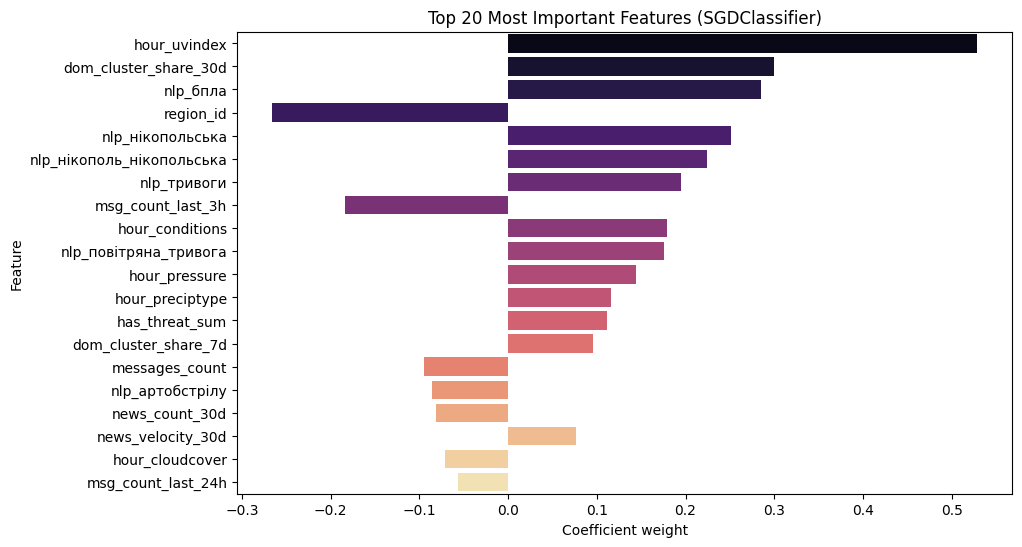

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top20,
    x="weight",
    y="feature",
    palette='magma'
)

plt.title("Top 20 Most Important Features (SGDClassifier)")
plt.xlabel("Coefficient weight")
plt.ylabel("Feature")

plt.show()